# Lifetime PD hazard model

The target is default in the next month conditional on survival through the current month.

In [1]:
from pathlib import Path
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
DB = ROOT / "database" / "ifrs9_ecl.sqlite3"

def query(sql):
    with sqlite3.connect(DB) as connection:
        return pd.read_sql_query(sql, connection)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

Conditional PD is q(t). Survival is S(t-1). Marginal PD is S(t-1) x q(t). Cumulative PD is the sum of marginal PD through month T.

In [2]:
query("select * from pd_model_metrics where model='discrete-time monthly hazard'")

,model,sample,rows,defaults,roc_auc,gini,ks,brier_score,observed_rate,predicted_rate
0,discrete-time monthly hazard,development,918261,584,0.9958,0.9917,0.9889,0.0003,0.0006,0.0007
1,discrete-time monthly hazard,out_of_time,80872,24,0.9998,0.9996,0.9995,0.0003,0.0003,0.0006


In [3]:
hazard_data = query("select * from pd_development_sample where target_name='monthly_hazard'")
hazard_numeric = ['classic_fico','original_dti','original_ltv','current_ltv','current_dpd','max_dpd_3m','max_dpd_6m','max_dpd_12m','current_actual_upb','current_interest_rate','modification_history','loan_age_sqrt','remaining_months_to_legal_maturity']
hazard_categorical = ['occupancy_status','loan_purpose','property_type']
hazard_features = hazard_numeric + hazard_categorical
hazard_prepare = ColumnTransformer([
 ('numeric',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),hazard_numeric),
 ('categorical',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),hazard_categorical)])
notebook_hazard = Pipeline([('prepare',hazard_prepare),('model',LogisticRegression(max_iter=500,C=.5))])
hazard_development = hazard_data[hazard_data.split.eq('development')]
notebook_hazard.fit(hazard_development[hazard_features], hazard_development.target,
                    model__sample_weight=hazard_development.observation_weight)
hazard_test = hazard_data[hazard_data.split.eq('out_of_time')]
hazard_probability = notebook_hazard.predict_proba(hazard_test[hazard_features])[:,1]
{'rows':len(hazard_test),'defaults':int(hazard_test.target.sum()),
 'weighted_auc':roc_auc_score(hazard_test.target,hazard_probability,sample_weight=hazard_test.observation_weight)}

{'rows': 2024, 'defaults': 24, 'weighted_auc': np.float64(0.9998333333333334)}

In [4]:
example_q = np.array([0.010,0.015,0.020])
example_survival = np.r_[1.0, np.cumprod(1-example_q)[:-1]]
example_mpd = example_survival*example_q
pd.DataFrame({'month':[1,2,3],'conditional_pd':example_q,'survival_at_start':example_survival,
              'marginal_pd':example_mpd,'cumulative_pd':example_mpd.cumsum()})

,month,conditional_pd,survival_at_start,marginal_pd,cumulative_pd
0,1,0.0100,1.0000,0.0100,0.0100
1,2,0.0150,0.9900,0.0148,0.0248
2,3,0.0200,0.9751,0.0195,0.0444


In [5]:
term = query("select * from pd_term_structure where stage=2 and scenario='Base' and future_month<=120")
term.head(15)

,stage,scenario,future_month,conditional_pd,survival_probability,marginal_pd,cumulative_pd
0,2,Base,1,0.0019,1.0000,0.0019,0.0019
1,2,Base,2,0.0011,0.9862,0.0010,0.0029
2,2,Base,3,0.0008,0.9735,0.0007,0.0036
3,2,Base,4,0.0007,0.9612,0.0006,0.0042
4,2,Base,5,0.0007,0.9492,0.0006,0.0048
5,2,Base,6,0.0007,0.9373,0.0006,0.0054
6,2,Base,7,0.0007,0.9256,0.0005,0.0059
7,2,Base,8,0.0007,0.9141,0.0005,0.0064
8,2,Base,9,0.0007,0.9027,0.0005,0.0070
9,2,Base,10,0.0007,0.8914,0.0005,0.0075


Text(0.5, 1.0, 'Stage 2 Base PD term structure')

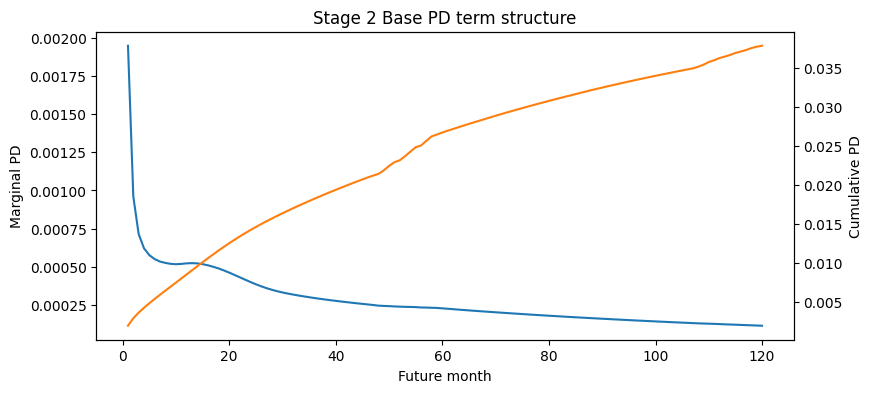

In [6]:
fig, ax1 = plt.subplots()
ax1.plot(term.future_month, term.marginal_pd, label='Marginal PD')
ax1.set_xlabel('Future month'); ax1.set_ylabel('Marginal PD')
ax2 = ax1.twinx(); ax2.plot(term.future_month, term.cumulative_pd, color='tab:orange')
ax2.set_ylabel('Cumulative PD'); ax1.set_title('Stage 2 Base PD term structure')

The near-perfect hazard ranking is treated cautiously because delinquency immediately before default is highly predictive. Target timing and leakage checks remain important.